In [1]:
import pandas as pd
import numpy as np
import plotly.express as px
import matplotlib.pyplot as plt
%matplotlib inline
import seaborn as sns

In [2]:
df = pd.read_csv(r"C:\Users\abhinandan\Desktop\FarmMitra\Data\Crop_recommendation.csv")

In [3]:
df.head()

,N,P,K,temperature,humidity,ph,rainfall,label
0,90,42,43,20.879744,82.002744,6.502985,202.935536,rice
1,85,58,41,21.770462,80.319644,7.038096,226.655537,rice
2,60,55,44,23.004459,82.320763,7.840207,263.964248,rice
3,74,35,40,26.491096,80.158363,6.980401,242.864034,rice
4,78,42,42,20.130175,81.604873,7.628473,262.717340,rice


In [4]:
df["label"].unique()

array(['rice', 'maize', 'chickpea', 'kidneybeans', 'pigeonpeas',
       'mothbeans', 'mungbean', 'blackgram', 'lentil', 'pomegranate',
       'banana', 'mango', 'grapes', 'watermelon', 'muskmelon', 'apple',
       'orange', 'papaya', 'coconut', 'cotton', 'jute', 'coffee'],
      dtype=object)

In [5]:
df["label"].value_counts()

label
rice           100
maize          100
jute           100
cotton         100
coconut        100
papaya         100
orange         100
apple          100
muskmelon      100
watermelon     100
grapes         100
mango          100
banana         100
pomegranate    100
lentil         100
blackgram      100
mungbean       100
mothbeans      100
pigeonpeas     100
kidneybeans    100
chickpea       100
coffee         100
Name: count, dtype: int64

In [6]:
df.describe()

,N,P,K,temperature,humidity,ph,rainfall
count,2200.000000,2200.000000,2200.000000,2200.000000,2200.000000,2200.000000,2200.000000
mean,50.551818,53.362727,48.149091,25.616244,71.481779,6.469480,103.463655
std,36.917334,32.985883,50.647931,5.063749,22.263812,0.773938,54.958389
min,0.000000,5.000000,5.000000,8.825675,14.258040,3.504752,20.211267
25%,21.000000,28.000000,20.000000,22.769375,60.261953,5.971693,64.551686
50%,37.000000,51.000000,32.000000,25.598693,80.473146,6.425045,94.867624
75%,84.250000,68.000000,49.000000,28.561654,89.948771,6.923643,124.267508
max,140.000000,145.000000,205.000000,43.675493,99.981876,9.935091,298.560117


In [7]:
df.isnull().sum()

N              0
P              0
K              0
temperature    0
humidity       0
ph             0
rainfall       0
label          0
dtype: int64

In [8]:
df.rename(columns={
    'N': 'nitrogen',
    'P': 'phosphorus',
    'K': 'potassium'
}, inplace=True)

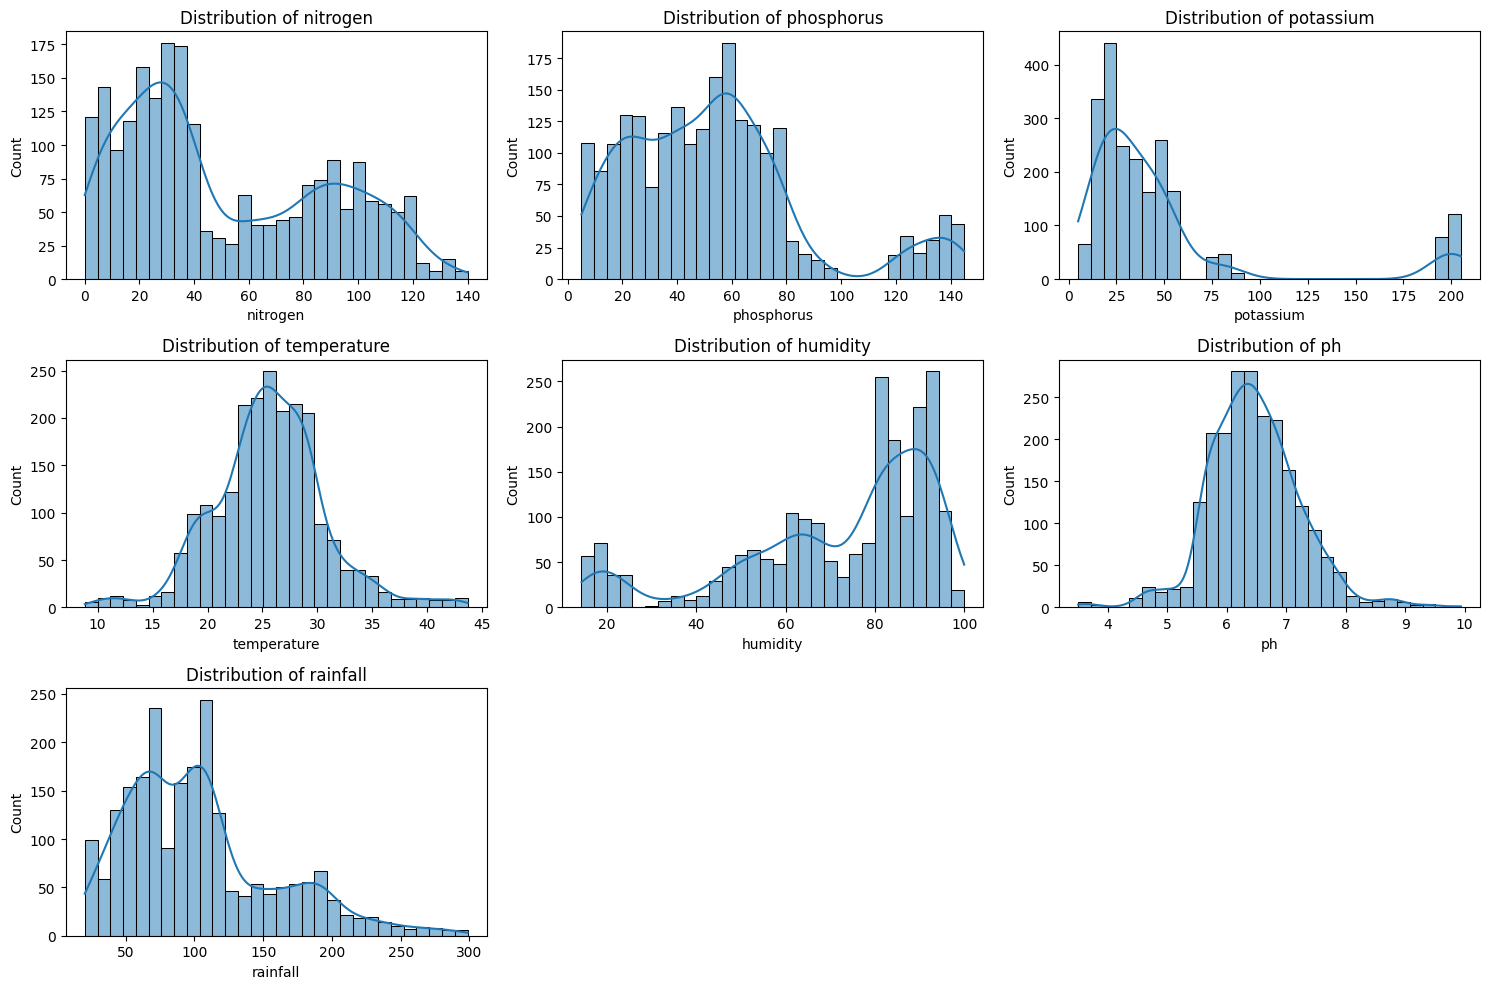

In [9]:
import matplotlib.pyplot as plt
import seaborn as sns

features = ['nitrogen', 'phosphorus', 'potassium', 'temperature', 'humidity', 'ph', 'rainfall']

plt.figure(figsize=(15, 10))
for i, feature in enumerate(features):
    plt.subplot(3, 3, i+1)
    sns.histplot(df[feature], kde=True, bins=30)
    plt.title(f'Distribution of {feature}')
plt.tight_layout()
plt.show()

In [10]:
crop_summary = pd.pivot_table(df,index=['label'],
                              aggfunc='mean')

In [11]:
crop_summary

,humidity,nitrogen,ph,phosphorus,potassium,rainfall,temperature
label,,,,,,,
apple,92.333383,20.80,5.929663,134.22,199.89,112.654779,22.630942
banana,80.358123,100.23,5.983893,82.01,50.05,104.626980,27.376798
blackgram,65.118426,40.02,7.133952,67.47,19.24,67.884151,29.973340
chickpea,16.860439,40.09,7.336957,67.79,79.92,80.058977,18.872847
coconut,94.844272,21.98,5.976562,16.93,30.59,175.686646,27.409892
coffee,58.869846,101.20,6.790308,28.74,29.94,158.066295,25.540477
cotton,79.843474,117.77,6.912675,46.24,19.56,80.398043,23.988958
grapes,81.875228,23.18,6.025937,132.53,200.11,69.611829,23.849575
jute,79.639864,78.40,6.732778,46.86,39.99,174.792798,24.958376


In [12]:
crop_summary_new = crop_summary.reset_index()

In [13]:
crop_summary_new

,label,humidity,nitrogen,ph,phosphorus,potassium,rainfall,temperature
0,apple,92.333383,20.80,5.929663,134.22,199.89,112.654779,22.630942
1,banana,80.358123,100.23,5.983893,82.01,50.05,104.626980,27.376798
2,blackgram,65.118426,40.02,7.133952,67.47,19.24,67.884151,29.973340
3,chickpea,16.860439,40.09,7.336957,67.79,79.92,80.058977,18.872847
4,coconut,94.844272,21.98,5.976562,16.93,30.59,175.686646,27.409892
5,coffee,58.869846,101.20,6.790308,28.74,29.94,158.066295,25.540477
6,cotton,79.843474,117.77,6.912675,46.24,19.56,80.398043,23.988958
7,grapes,81.875228,23.18,6.025937,132.53,200.11,69.611829,23.849575
8,jute,79.639864,78.40,6.732778,46.86,39.99,174.792798,24.958376
9,kidneybeans,21.605357,20.75,5.749411,67.54,20.05,105.919778,20.115085


C:\Users\abhinandan\AppData\Local\Temp\ipykernel_16628\3462907855.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(y = 'nitrogen', x = 'label', data=crop_summary_new, palette = 'hls')


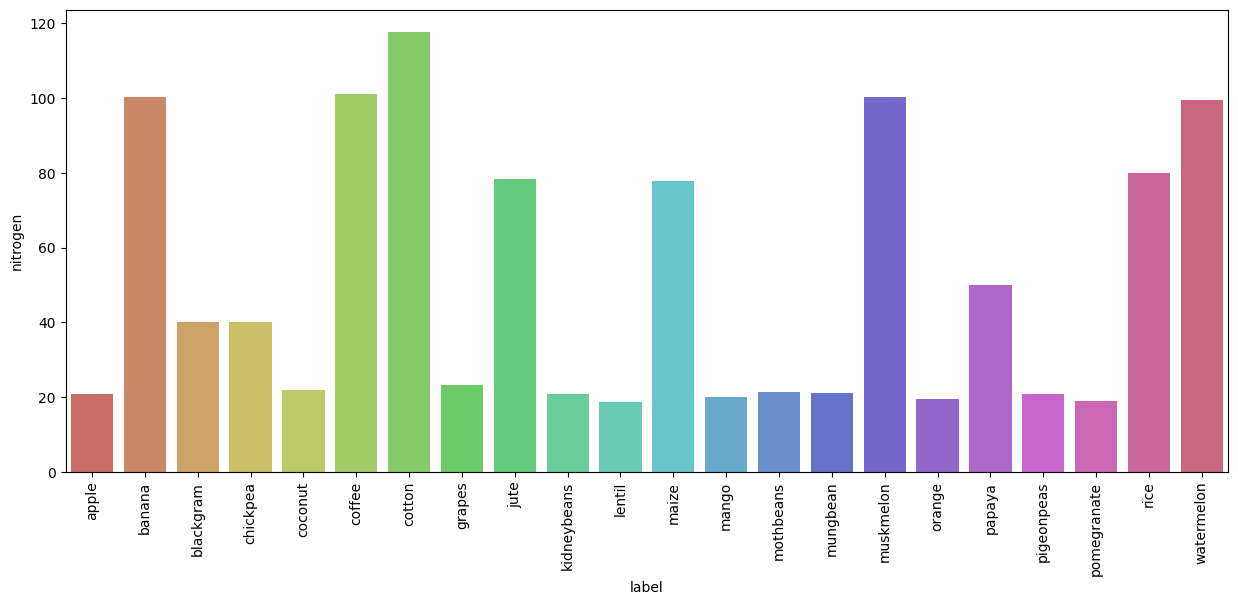

In [14]:
plt.figure(figsize=(15,6))
sns.barplot(y = 'nitrogen', x = 'label', data=crop_summary_new, palette = 'hls')
plt.xticks(rotation = 90)
plt.show()

C:\Users\abhinandan\AppData\Local\Temp\ipykernel_16628\1027163252.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(y = 'ph', x = 'label', data=crop_summary_new, palette = 'hls')


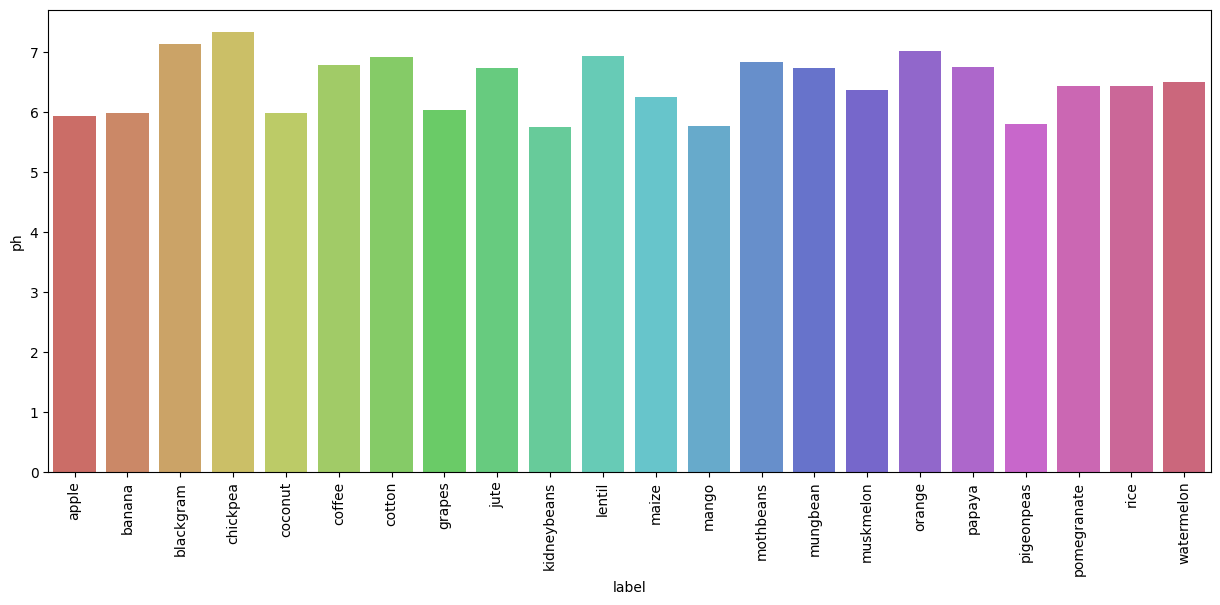

In [15]:
plt.figure(figsize=(15,6))
sns.barplot(y = 'ph', x = 'label', data=crop_summary_new, palette = 'hls')
plt.xticks(rotation = 90)
plt.show()

C:\Users\abhinandan\AppData\Local\Temp\ipykernel_16628\4283081211.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(y = 'humidity', x = 'label', data=crop_summary_new, palette = 'hls')


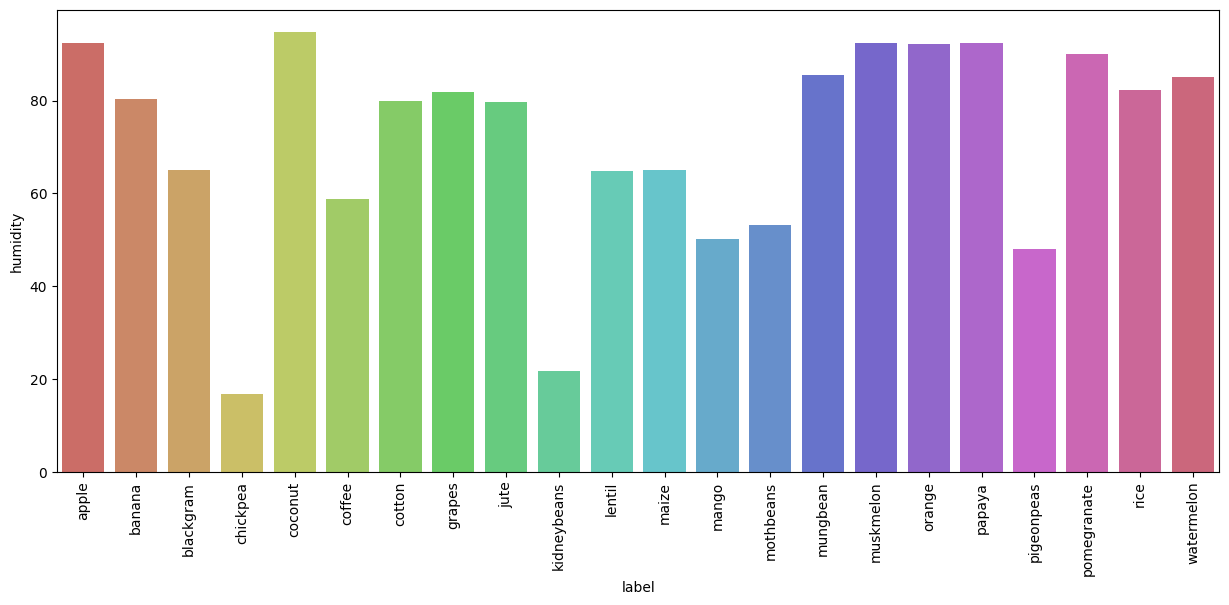

In [16]:
plt.figure(figsize=(15,6))
sns.barplot(y = 'humidity', x = 'label', data=crop_summary_new, palette = 'hls')
plt.xticks(rotation = 90)
plt.show()

C:\Users\abhinandan\AppData\Local\Temp\ipykernel_16628\746860520.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(y = 'phosphorus', x = 'label', data=crop_summary_new, palette = 'hls')


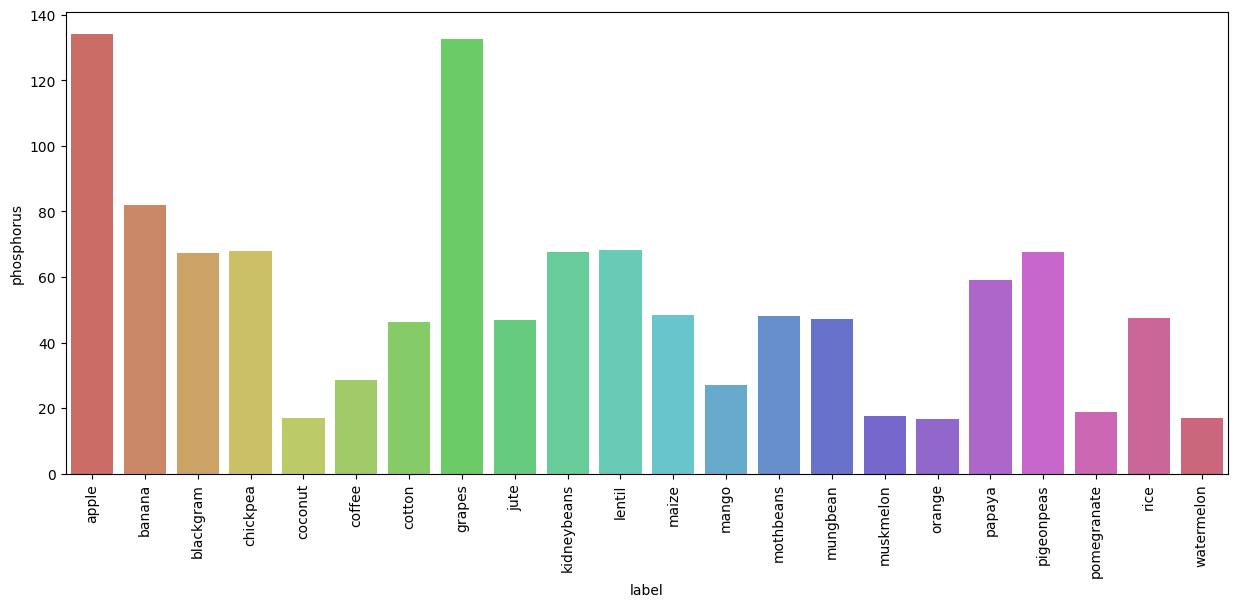

In [17]:
plt.figure(figsize=(15,6))
sns.barplot(y = 'phosphorus', x = 'label', data=crop_summary_new, palette = 'hls')
plt.xticks(rotation = 90)
plt.show()

C:\Users\abhinandan\AppData\Local\Temp\ipykernel_16628\3268702060.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(y = 'potassium', x = 'label', data=crop_summary_new, palette = 'hls')


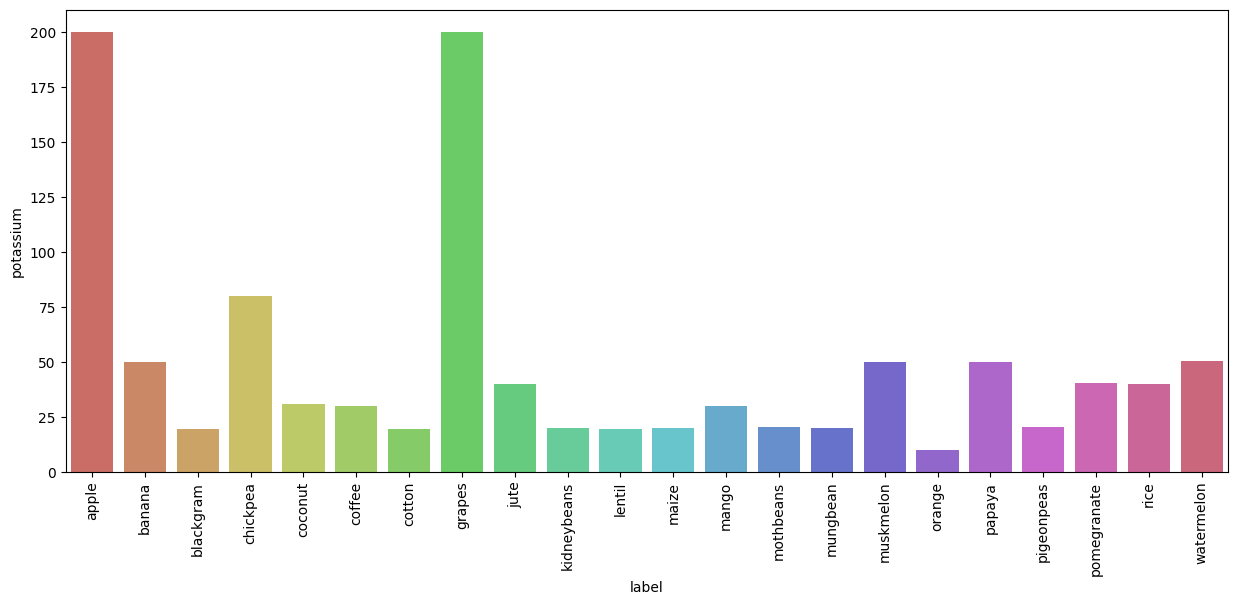

In [18]:

plt.figure(figsize=(15,6))
sns.barplot(y = 'potassium', x = 'label', data=crop_summary_new, palette = 'hls')
plt.xticks(rotation = 90)
plt.show()

C:\Users\abhinandan\AppData\Local\Temp\ipykernel_16628\1883476861.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(y = 'rainfall', x = 'label', data=crop_summary_new, palette = 'hls')


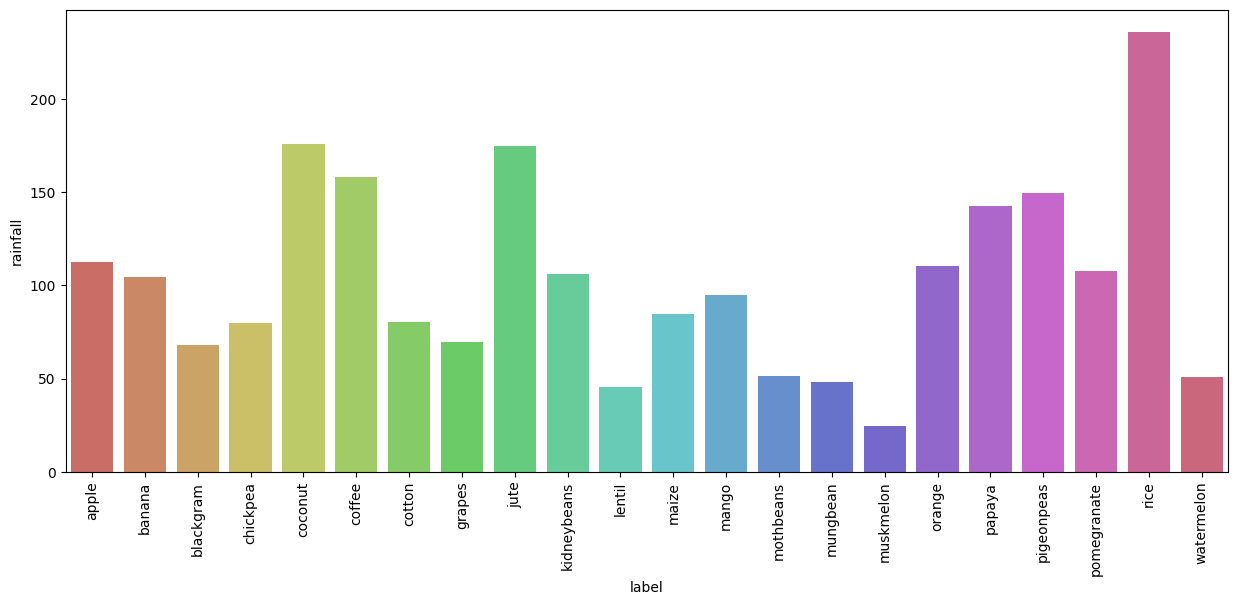

In [19]:
plt.figure(figsize=(15,6))
sns.barplot(y = 'rainfall', x = 'label', data=crop_summary_new, palette = 'hls')
plt.xticks(rotation = 90)
plt.show()

C:\Users\abhinandan\AppData\Local\Temp\ipykernel_16628\1666136163.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(y = 'temperature', x = 'label', data=crop_summary_new, palette = 'hls')


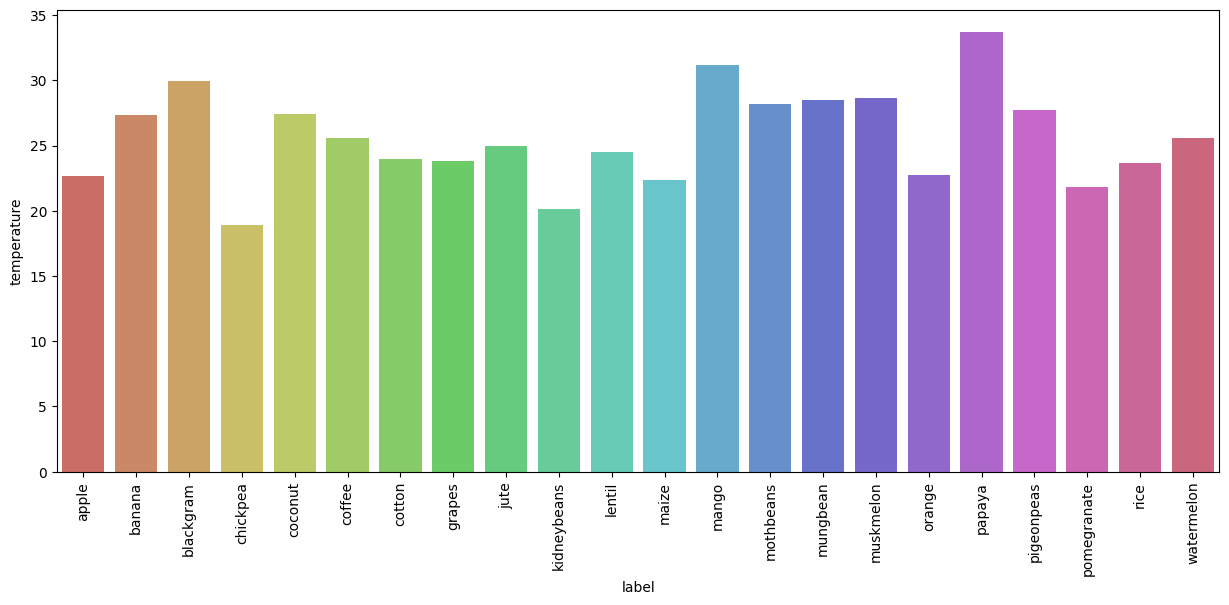

In [20]:
plt.figure(figsize=(15,6))
sns.barplot(y = 'temperature', x = 'label', data=crop_summary_new, palette = 'hls')
plt.xticks(rotation = 90)
plt.show()

In [21]:
fig = px.bar(crop_summary, x=crop_summary.index, y=["rainfall", "temperature", "humidity"])
fig.update_layout(title_text="Comparision between rainfall, temerature and humidity",
                  plot_bgcolor='white',
                 height=500)

fig.update_xaxes(showgrid=False)
fig.update_yaxes(showgrid=False)
fig.show()

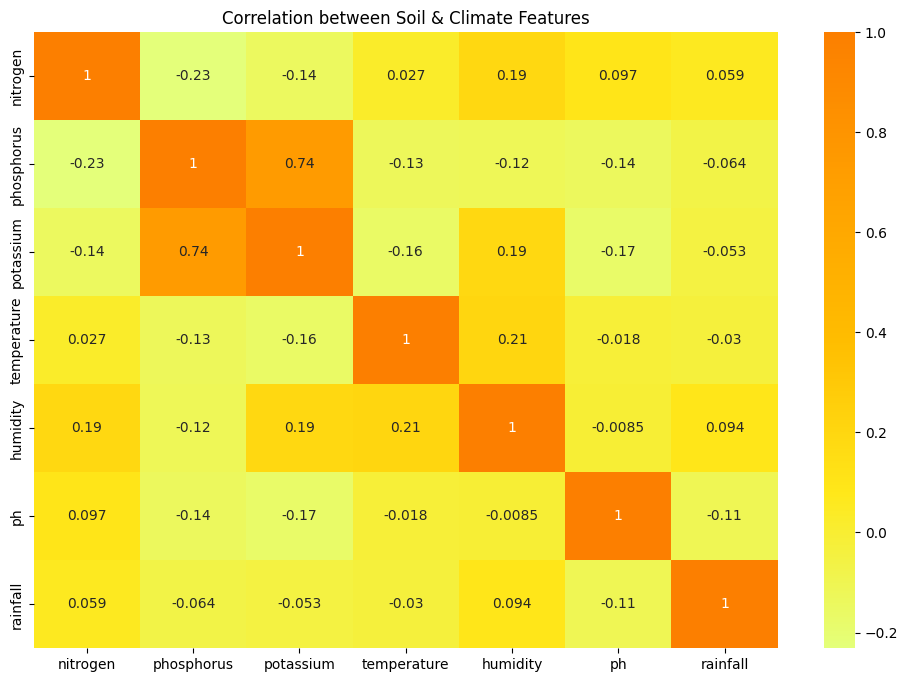

In [22]:
numeric_df = df.drop('label', axis=1)

import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(12, 8))
sns.heatmap(numeric_df.corr(), annot=True, cmap='Wistia')
plt.title('Correlation between Soil & Climate Features')
plt.show()


In [23]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score , classification_report ,confusion_matrix

In [24]:
x = df.drop("label",axis=1)
y = df['label']

In [25]:
x_train, x_test, y_train, y_test = train_test_split(x,y, test_size=0.1,random_state=42)

In [26]:
model = RandomForestClassifier()
model.fit(x_train,y_train)

RandomForestClassifier()

In [27]:
y_pred = model.predict(x_test)

print("Accuracy:", accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred))

Accuracy: 1.0
              precision    recall  f1-score   support

       apple       1.00      1.00      1.00         9
      banana       1.00      1.00      1.00        12
   blackgram       1.00      1.00      1.00        13
    chickpea       1.00      1.00      1.00        13
     coconut       1.00      1.00      1.00        15
      coffee       1.00      1.00      1.00         9
      cotton       1.00      1.00      1.00         6
      grapes       1.00      1.00      1.00         8
        jute       1.00      1.00      1.00        11
 kidneybeans       1.00      1.00      1.00        13
      lentil       1.00      1.00      1.00         7
       maize       1.00      1.00      1.00        12
       mango       1.00      1.00      1.00         4
   mothbeans       1.00      1.00      1.00        11
    mungbean       1.00      1.00      1.00        10
   muskmelon       1.00      1.00      1.00         7
      orange       1.00      1.00      1.00         9
      papaya 

In [ ]:
import joblib
import os
os.makedirs("models", exist_ok=True)

joblib.dump(model, "models/farmmitra_crop_model.pkl")

['models/farmmitra_crop_model.pkl']

In [34]:
import joblib
crop_model = joblib.load('models/farmmitra_crop_model.pkl')

In [ ]:
print(type(model))

<class 'sklearn.ensemble._forest.RandomForestClassifier'>


In [36]:
def predict_crop_from_user():
    print("👉 Enter the following values:")

    nitrogen = float(input("Nitrogen (N): "))
    phosphorus = float(input("Phosphorus (P): "))
    potassium = float(input("Potassium (K): "))
    temperature = float(input("Temperature (°C): "))
    humidity = float(input("Humidity (%): "))
    ph = float(input("pH level: "))
    rainfall = float(input("Rainfall (mm): "))

    input_features = [[nitrogen, phosphorus, potassium, temperature, humidity, ph, rainfall]]

    prediction = model.predict(input_features)
    
    print("\nRecommended Crop: ", prediction[0].capitalize())

predict_crop_from_user()


👉 Enter the following values:

Recommended Crop:  Muskmelon


c:\Users\abhinandan\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\utils\validation.py:2739: UserWarning:

X does not have valid feature names, but RandomForestClassifier was fitted with feature names

